# Session 2: Foundations of differential equations in physics (Part 2)

Building on Session 1, where we reviewed the heat and wave equations and introduced explicit finite differences, this week we shall explore more robust numerical schemes, extend them to higher dimensions, and discuss the key limitations of traditional grid-based methods. These challenges are precisely what motivate the development of mesh-free approaches like PINNs.

## 1. Implicit and Semi-Implicit Schemes for the Heat Equation
s
The explicit FTCS scheme from Session 1 is simple but conditionally stable (requires small $\Delta t$). For practical problems, we often prefer unconditionally stable methods.

**Implicit (Backward Euler) Scheme**  

$$
u_i^{n+1} - r (u_{i-1}^{n+1} - 2u_i^{n+1} + u_{i+1}^{n+1}) = u_i^n
$$

This leads to a tridiagonal linear system to solve at each time step—more work per step, but allows much larger $\Delta t$.

**Crank-Nicolson Scheme** (semi-implicit, second-order accurate in time)  

Averages explicit and implicit:  

$$
u_i^{n+1} - \frac{r}{2} (u_{i-1}^{n+1} - 2u_i^{n+1} + u_{i+1}^{n+1}) = u_i^n + \frac{r}{2} (u_{i-1}^n - 2u_i^n + u_{i+1}^n)
$$

Also tridiagonal, unconditionally stable, and very popular.


Here we have a demonstration of some typical finite difference stencils, including the Crank-Nicolson averaging over time levels:

[Crank-Nicolson Scheme](https://www.youtube.com/watch?v=qpBUHDtORyY)

![Crank-Nicolson stencil](figures/Crank-Nicolson-stencil.svg)

## 2. Higher Dimensions and Other PDEs

In 2D/3D, the principles are similar but grids grow rapidly.

**2D Heat Equation**:
 
 $$\frac{\partial u}{\partial t} = \alpha (\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2})$$

Finite difference stencil becomes 5-point (cross) in 2D. The following illustration is taken from https://john-s-butler-dit.github.io/NumericalAnalysisBook/Chapter%2009%20-%20Elliptic%20Equations/901_Poisson%20Equation-Laplacian.html

![Discrete grid](figures/discrete_grid.png)


**Laplace/Poisson Equation in 2D**: 

$$\nabla^2 \phi = f(x,y)$$

Steady-state: iterative solvers like Jacobi, Gauss-Seidel, or SOR on the 5-point stencil:

$$
\phi_{i,j} = \frac{1}{4} (\phi_{i+1,j} + \phi_{i-1,j} + \phi_{i,j+1} + \phi_{i,j-1} - h^2 f_{i,j})
$$


See [Solving 2D Laplace Equation Made EASY with Finite Differences](https://www.youtube.com/watch?v=79rWWwbqxbQ)

Here is a quick Python example for the 2D Poisson equation $\nabla^2 \phi = -2\pi^2 \sin(\pi x)\sin(\pi y)$, with the analytic solution $\phi = \sin(\pi x)\sin(\pi y)$, using Gauss-Seidel iteration:


Converged after 2589 iterations


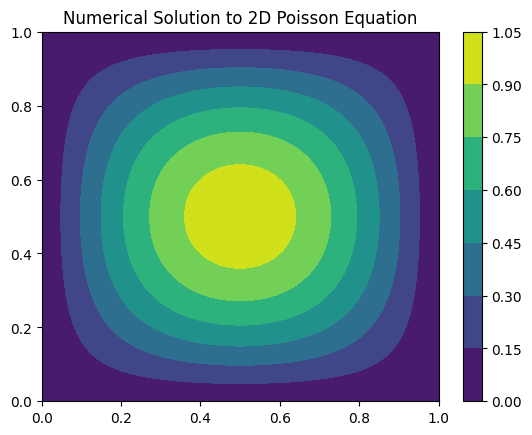

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Nx = Ny = 50
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y)

phi = np.zeros((Nx, Ny))  # initial guess
f = -2 * np.pi**2 * np.sin(np.pi * X) * np.sin(np.pi * Y)

max_iter = 10000
tol = 1e-5
for iter in range(max_iter):
    phi_old = phi.copy()
    phi[1:-1, 1:-1] = 0.25 * (phi[2:, 1:-1] + phi[:-2, 1:-1] +
                              phi[1:-1, 2:] + phi[1:-1, :-2] -
                              (1/(Nx-1))**2 * f[1:-1, 1:-1])
    if np.max(np.abs(phi - phi_old)) < tol:
        print(f"Converged after {iter} iterations")
        break

plt.contourf(X, Y, phi)
plt.colorbar()
plt.title('Numerical Solution to 2D Poisson Equation')
plt.show()

## 3. Finite Difference Stencils in General
Common stencils for second derivatives:

![Finite-difference stencil for 3D explicit time marching](figures/Finite-difference-stencil-for-3D-explicit-time-marching.png)

![9-point stencil](figures/9-point_stencil.png)

These illustrate 1D/2D/3D stencils used in explicit/implicit schemes.

## 4. Limitations of Traditional Numerical Methods
- **Stability restrictions**: Explicit schemes require tiny time steps.
- **Mesh generation**: Structured grids are simple but struggle with complex geometries. Unstructured meshes (finite volume/element methods) are flexible but require sophisticated meshing software.

![Structured and unstructured mesh 1](figures/fig4_4.jpg)
![Structurd and unstructured mesh 2](figures/fig4_5.jpg)





- **Curse of dimensionality**: Grid points grow exponentially with dimensions (e.g., 10 points per dimension → 10^d points). Impractical beyond 3-4D (common in phase space, parameter studies).

![Illustrations of the curse of dimensionality](figures/llustrations-of-the-curse-of-dimensionality.webp)
![The curse of dimenstionality in classification](figures/dimensionality_vs_performance.png)




- **Data handling**: Traditional methods excel with no data, but incorporating sparse/noisy measurements is tricky.

These pain points are why PINNs are exciting: mesh-free, handle high dimensions better, naturally incorporate data and physics, and scale with modern GPUs.

**Reading**: Chapters on finite differences in Randal J. LeVeque's *Finite Difference Methods for Ordinary and Partial Differential Equations* or sections in William H.Press et al. *Numerical Recipes*.

Next session: Neural networks basics! Get ready to code some simple function approximation.

